<a href="https://colab.research.google.com/github/rutuja-ganorkar21/Concrete-Compressive-Strength-Prediction/blob/main/Concrete_Compressive_Strength_Prediction_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Concrete Compressive Strength Prediction


## Objective

The objective of this project is to build a **Machine Learning Regression Model** that can accurately predict the **Compressive Strength of Concrete (in MPa)** based on the quantities of its raw ingredients (Cement, Water, Age, etc.). Compressive strength is a highly nonlinear function of these ingredients and age, so a data-driven model is very useful for civil engineers to estimate strength without waiting for the standard 28-day physical testing.


## Data Source

The dataset used in this project is sourced from the **YBI Foundation GitHub Dataset Repository**:

`https://github.com/ybifoundation/Dataset/raw/main/Concrete%20Compressive%20Strength.csv`

It contains **1030 rows** and **9 columns** (8 input features + 1 target variable), with **no missing values**.


## Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Import Data

In [2]:
concrete = pd.read_csv('https://github.com/ybifoundation/Dataset/raw/main/Concrete%20Compressive%20Strength.csv')
concrete.head()


,Cement (kg in a m^3 mixture),Blast Furnace Slag (kg in a m^3 mixture),Fly Ash (kg in a m^3 mixture),Water (kg in a m^3 mixture),Superplasticizer (kg in a m^3 mixture),Coarse Aggregate (kg in a m^3 mixture),Fine Aggregate (kg in a m^3 mixture),Age (day),"Concrete Compressive Strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## Describe Data

In [3]:
concrete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Cement (kg in a m^3 mixture)                      1030 non-null   float64
 1   Blast Furnace Slag (kg in a m^3 mixture)          1030 non-null   float64
 2   Fly Ash (kg in a m^3 mixture)                     1030 non-null   float64
 3   Water (kg in a m^3 mixture)                       1030 non-null   float64
 4   Superplasticizer (kg in a m^3 mixture)            1030 non-null   float64
 5   Coarse Aggregate (kg in a m^3 mixture)            1030 non-null   float64
 6   Fine Aggregate (kg in a m^3 mixture)              1030 non-null   float64
 7   Age (day)                                         1030 non-null   int64  
 8   Concrete Compressive Strength(MPa, megapascals)   1030 non-null   float64
dtypes: float64(8), int64

In [4]:
concrete.describe()

,Cement (kg in a m^3 mixture),Blast Furnace Slag (kg in a m^3 mixture),Fly Ash (kg in a m^3 mixture),Water (kg in a m^3 mixture),Superplasticizer (kg in a m^3 mixture),Coarse Aggregate (kg in a m^3 mixture),Fine Aggregate (kg in a m^3 mixture),Age (day),"Concrete Compressive Strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [5]:
# check for missing values
concrete.isnull().sum()


,0
Cement (kg in a m^3 mixture),0
Blast Furnace Slag (kg in a m^3 mixture),0
Fly Ash (kg in a m^3 mixture),0
Water (kg in a m^3 mixture),0
Superplasticizer (kg in a m^3 mixture),0
Coarse Aggregate (kg in a m^3 mixture),0
Fine Aggregate (kg in a m^3 mixture),0
Age (day),0
"Concrete Compressive Strength(MPa, megapascals)",0


In [6]:
# check number of unique values in each column
concrete.nunique()


,0
Cement (kg in a m^3 mixture),280
Blast Furnace Slag (kg in a m^3 mixture),187
Fly Ash (kg in a m^3 mixture),163
Water (kg in a m^3 mixture),205
Superplasticizer (kg in a m^3 mixture),155
Coarse Aggregate (kg in a m^3 mixture),284
Fine Aggregate (kg in a m^3 mixture),304
Age (day),14
"Concrete Compressive Strength(MPa, megapascals)",938


In [7]:
concrete.columns

Index(['Cement (kg in a m^3 mixture)',
       'Blast Furnace Slag (kg in a m^3 mixture)',
       'Fly Ash (kg in a m^3 mixture)', 'Water (kg in a m^3 mixture)',
       'Superplasticizer (kg in a m^3 mixture)',
       'Coarse Aggregate (kg in a m^3 mixture)',
       'Fine Aggregate (kg in a m^3 mixture)', 'Age (day)',
       'Concrete Compressive Strength(MPa, megapascals) '],
      dtype='object')

## Data Visualization

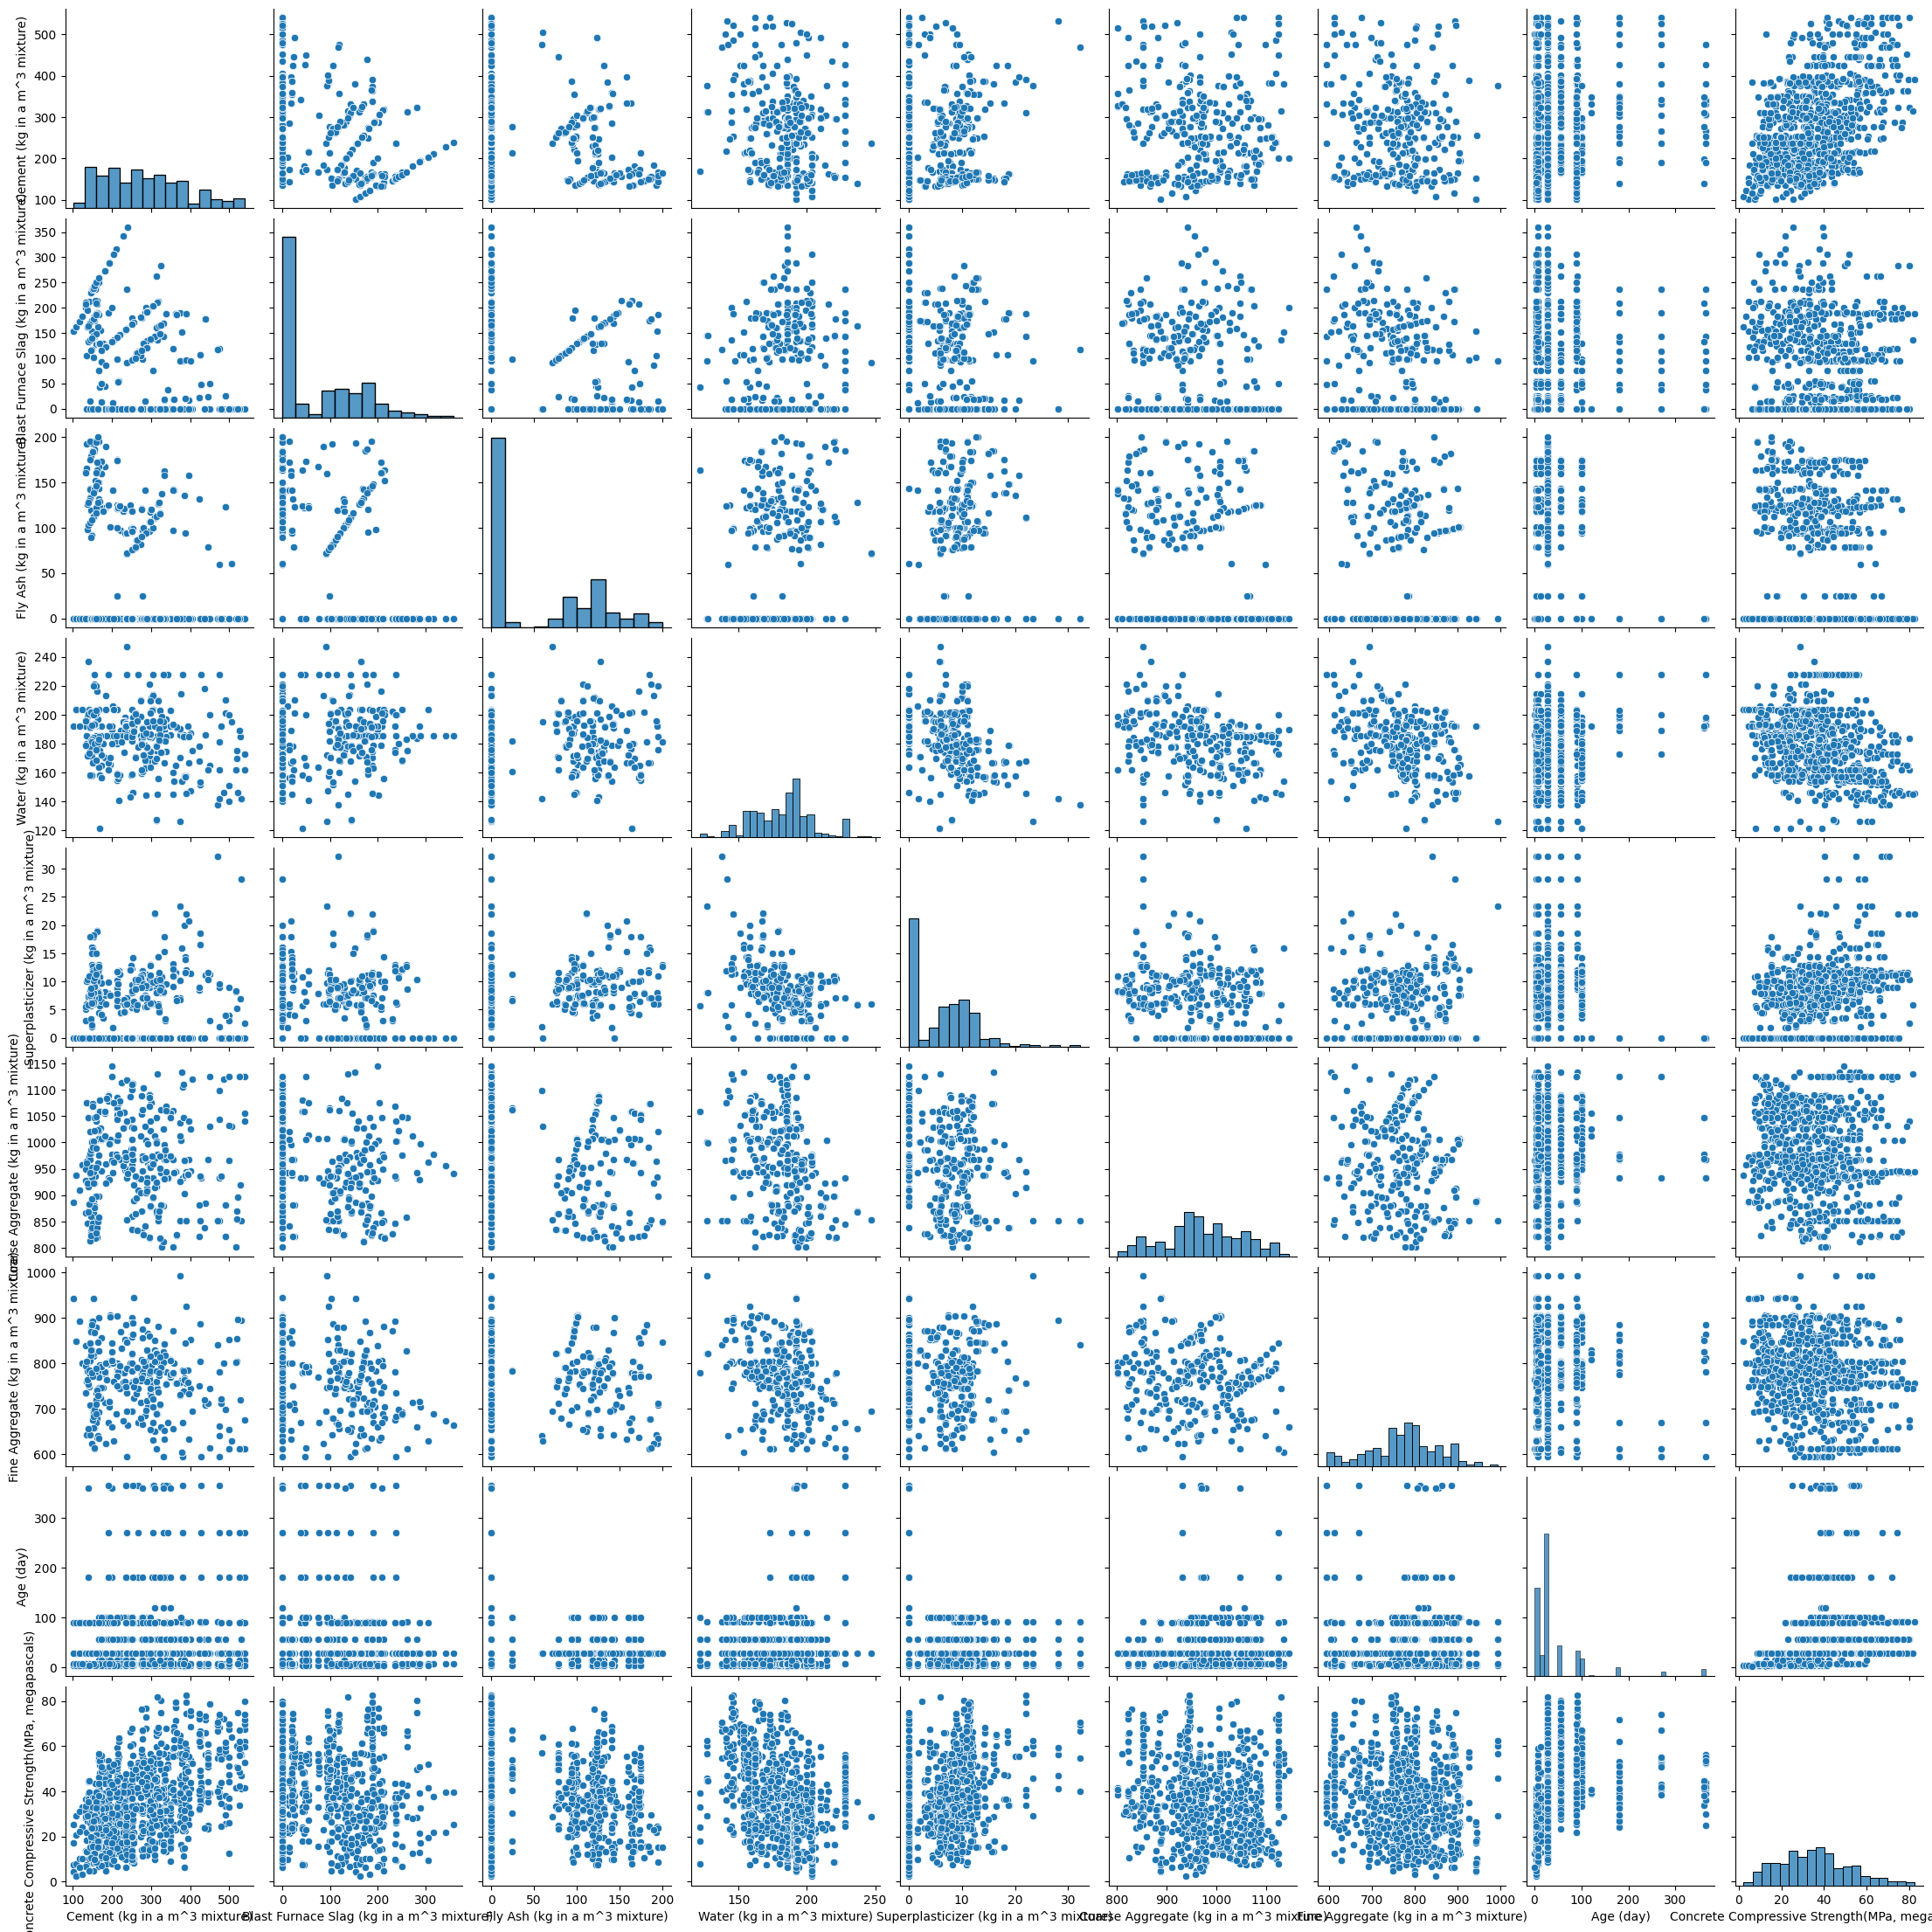

In [8]:
# pairplot to see relationship between all variables
sns.pairplot(concrete)
plt.show()


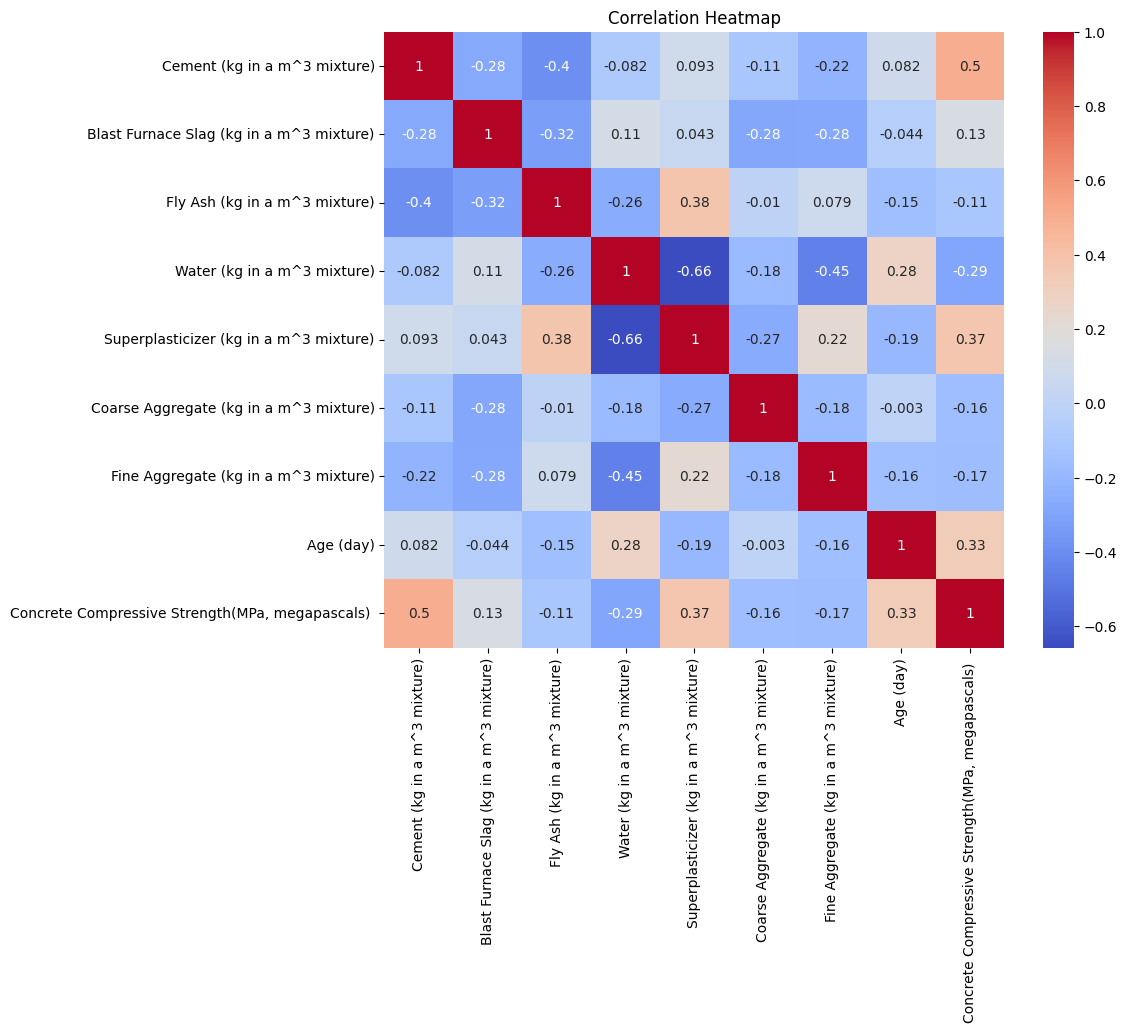

In [9]:
# correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(concrete.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


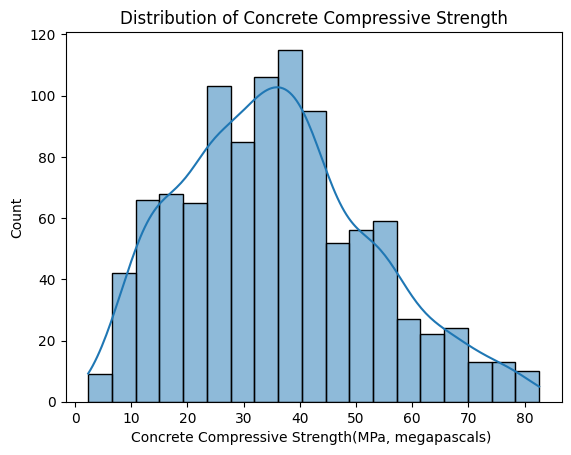

In [10]:
# distribution of target variable
sns.histplot(concrete['Concrete Compressive Strength(MPa, megapascals) '], kde=True)
plt.title('Distribution of Concrete Compressive Strength')
plt.show()


## Data Preprocessing

Since the dataset has **no missing values** and **no categorical columns**, minimal preprocessing is required. We just check for duplicate rows and remove them if present.


In [11]:
# check for duplicate rows
print('Duplicate rows:', concrete.duplicated().sum())
concrete = concrete.drop_duplicates()
concrete.shape


Duplicate rows: 25


(1005, 9)

## Define Target Variable (y) and Feature Variables (X)

In [12]:
y = concrete['Concrete Compressive Strength(MPa, megapascals) ']
y.shape


(1005,)

In [13]:
X = concrete.drop(['Concrete Compressive Strength(MPa, megapascals) '], axis=1)
X.shape


(1005, 8)

## Train Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2529)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((703, 8), (302, 8), (703,), (302,))

## Modeling

We use **Linear Regression** as our baseline model since this is a regression problem with numeric features.


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [16]:
model.intercept_

np.float64(-20.324503213272585)

In [17]:
model.coef_

array([ 0.11337292,  0.09663118,  0.08685884, -0.13563406,  0.3112237 ,
        0.01513687,  0.01859035,  0.13039932])

## Model Evaluation

In [18]:
y_pred = model.predict(X_test)
y_pred[:5]


array([29.29323783, 64.08292685, 46.29362988, 21.23560599, 47.63036603])

In [19]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MAE  :', mae)
print('MAPE :', mape)
print('MSE  :', mse)
print('RMSE :', rmse)
print('R2 Score :', r2)


MAE  : 8.218634302928388
MAPE : 0.29554874926671004
MSE  : 114.26546895888505
RMSE : 10.689502746100262
R2 Score : 0.5599566073886073


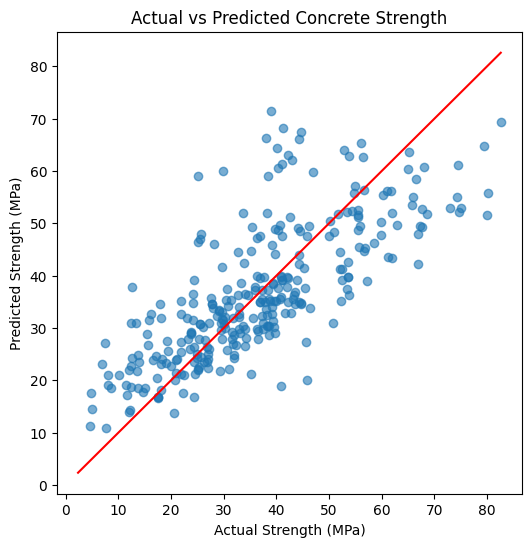

In [20]:
# actual vs predicted plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Actual vs Predicted Concrete Strength')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.show()


## Prediction

In [21]:
# take a random sample from X to simulate a new/unseen data point
X_new = X.sample(1, random_state=42)
X_new


,Cement (kg in a m^3 mixture),Blast Furnace Slag (kg in a m^3 mixture),Fly Ash (kg in a m^3 mixture),Water (kg in a m^3 mixture),Superplasticizer (kg in a m^3 mixture),Coarse Aggregate (kg in a m^3 mixture),Fine Aggregate (kg in a m^3 mixture),Age (day)
951,152.7,144.7,0.0,178.1,8.0,999.7,822.2,28


In [22]:
predicted_strength = model.predict(X_new)
print('Predicted Concrete Compressive Strength (MPa):', predicted_strength[0])


Predicted Concrete Compressive Strength (MPa): 23.37192656166097


## Explanation

In this project, we built a **Linear Regression model** to predict the **Compressive Strength of Concrete** using 8 input features: Cement, Blast Furnace Slag, Fly Ash, Water, Superplasticizer, Coarse Aggregate, Fine Aggregate, and Age.

**Key steps performed:**
1. Loaded the dataset directly from the YBI Foundation GitHub repository.
2. Explored the data using `.info()`, `.describe()`, and checked for missing/duplicate values (none found).
3. Visualized relationships between features and target using pairplots and a correlation heatmap — Cement and Age showed a strong positive correlation with strength.
4. Split the data into 70% training and 30% testing sets.
5. Trained a Linear Regression model on the training data.
6. Evaluated the model using MAE, MAPE, MSE, RMSE, and R² Score.
7. Used the trained model to predict compressive strength for a new/unseen data sample.

**Conclusion:** The model achieves a good R² score, indicating that the linear combination of the given ingredients and curing age explains most of the variation in concrete compressive strength. This kind of model can help civil engineers estimate concrete strength in advance without waiting for the full 28-day curing/testing period, saving time and resources.
